# Chapter 3 — From chosen to learned kernels

*Companion notebook to **The Learned Kernel**, Ch. 3. Run top to bottom.*

Chapter 2 showed the kernel is the only real degree of freedom. So stop *choosing* it
and start *learning* it. This notebook makes the central inversion concrete on the
running data: the bandwidth "choice" was the model all along; a learnable per-feature
geometry (ARD), fit on a held-out fold, beats the best bandwidth you could pick; and the
`(K, λ) → (αK, αλ)` scale degeneracy — which the unit-diagonal convention removes.

**The frame** — *what is learned · how scored · what you read off.* What is learned: the
per-feature length scales (the anisotropic metric). How scored: a **held-out** query
loss — and §"Two ways to overfit" is why that must be held out. What you read off: the
relevances 1/ℓ_j (local sensitivity), with Population switched off.

## Setup

In [1]:
# On Google Colab (or any fresh env) install the companion package; no-op locally.
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from lkbook import load_california, set_style
from lkbook.chapters import ch03

set_style()
cal = load_california()
print(f"California: {cal.n} train rows, {cal.d} features")

California: 16512 train rows, 8 features


## 3.1  The cost of choosing

Sweep the RBF bandwidth ℓ across two orders of magnitude and plot test RMSE. The curve
is sharply U-shaped — the "choice" of ℓ was carrying the entire model.

best RMSE 0.631 at ℓ=2.02;  worst 1.177 at ℓ=0.10;  gap 0.55


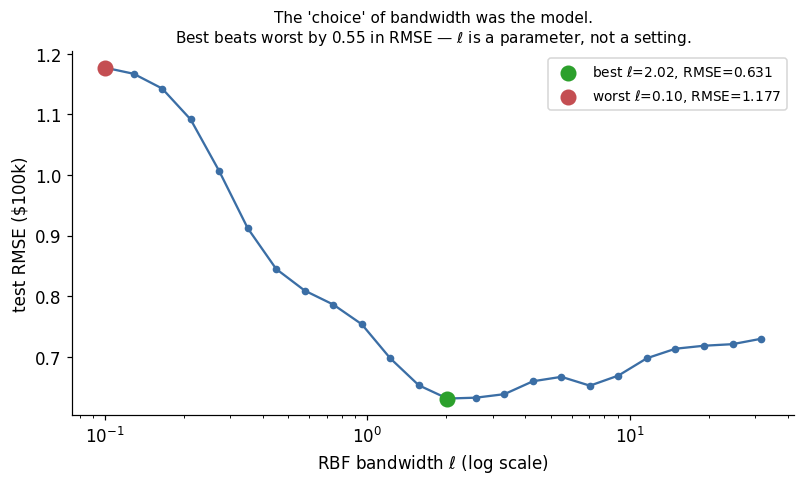

In [3]:
ells, rmse = ch03.bandwidth_sweep(cal)
print(f"best RMSE {rmse.min():.3f} at ℓ={ells[np.argmin(rmse)]:.2f};  "
      f"worst {rmse.max():.3f} at ℓ={ells[np.argmax(rmse)]:.2f};  "
      f"gap {rmse.max()-rmse.min():.2f}")
ch03.make_bandwidth_figure(cal)
plt.show()

A single scalar moves typical error by ~$55k. That is not a setting; it is a parameter.
So make the geometry an explicit function of parameters and fit it.

## 3.2  Parameterizing and learning the geometry (ARD)

Give each feature its own length scale, ℓ_j, and fit {log ℓ_j} by minimizing a
**held-out** query loss. (The fit takes ~20s.)

learned ARD test RMSE = 0.592
best isotropic   RMSE = 0.639  (ℓ=2.02)

relevances 1/ℓ_j (per-feature local sensitivity):
  AveOccup     1.296
  Longitude    1.157
  AveBedrms    0.546
  Latitude     0.524
  MedInc       0.256
  AveRooms     0.183
  HouseAge     0.154
  Population   0.001


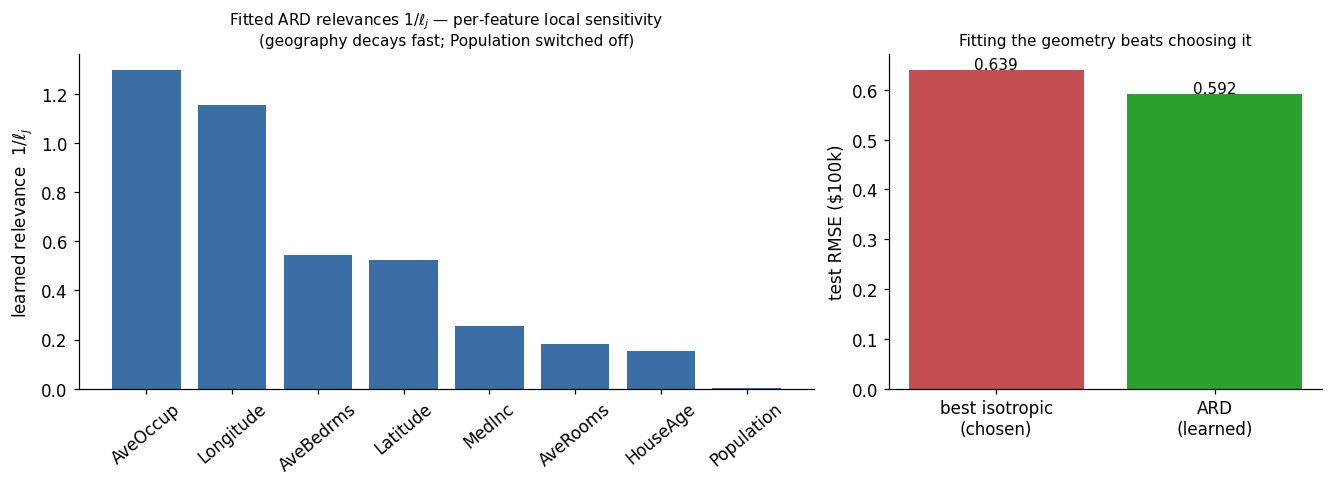

In [4]:
r = ch03.fit_ard(cal)
print(f"learned ARD test RMSE = {r['ard_test_rmse']:.3f}")
print(f"best isotropic   RMSE = {r['iso_test_rmse']:.3f}  (ℓ={r['best_iso_ell']:.2f})")
print("\nrelevances 1/ℓ_j (per-feature local sensitivity):")
for name, rel in sorted(zip(r["names"], r["relevance"]), key=lambda t: -t[1]):
    print(f"  {name:12s} {rel:.3f}")
ch03.make_ard_figure(cal)
plt.show()

The learned anisotropic geometry beats the best chosen isotropic one. Read 1/ℓ_j as
**local sensitivity**, not raw importance: geography decays fast (wiggly at neighborhood
scale), Population is switched off, and median income ranks low because its effect is a
*smooth* global trend (large ℓ), not because it is unimportant.

## 3.3  The identifiability trap and the unit-diagonal fix

KRR predictions are invariant under (K, λ) → (αK, αλ): the scale of the kernel and the
ridge trade off freely. Constraining the diagonal to 1 removes the free scale, so λ
becomes identifiable. The ARD/RBF kernel is unit-diagonal by construction.

In [5]:
deg = ch03.degeneracy_demo(cal, alpha=2.0)
print(f"prediction with (K, λ)    : {deg['pred_base']:.6f}")
print(f"prediction with (2K, 2λ)  : {deg['pred_scaled']:.6f}")
print(f"|Δ| = {deg['abs_diff']:.2e}   (invariant to machine precision)")
print(f"kernel diagonal = {deg['unit_diagonal']:.3f}  (unit ⟹ λ identifiable)")

prediction with (K, λ)    : 3.279868
prediction with (2K, 2λ)  : 3.279868
|Δ| = 0.00e+00   (invariant to machine precision)
kernel diagonal = 1.000  (unit ⟹ λ identifiable)


### Feel the cost of choosing

Slide the isotropic bandwidth ℓ and watch its test RMSE against the learned-ARD baseline
(dashed). Almost every hand-pick is worse than the geometry the data fit themselves.

In [6]:
from ipywidgets import interact, FloatSlider

_ard = r["ard_test_rmse"]


def explore(log10_ell=np.log10(2.0)):
    ell = 10.0 ** log10_ell
    e, rm = ch03.bandwidth_sweep(cal)
    Xs, ys, _, _ = ch03._split(cal)
    K = ch03.iso_gram(Xs, Xs, ell)
    a = np.linalg.solve(K + 1e-2 * np.eye(len(ys)), ys - ys.mean())
    this = float(np.sqrt(np.mean(
        (ch03.iso_gram(cal.Xte, Xs, ell) @ a + ys.mean() - cal.yte) ** 2)))
    fig, ax = plt.subplots(figsize=(7.2, 4))
    ax.semilogx(e, rm, "-", color="#bbbbbb", zorder=1)
    ax.axhline(_ard, ls="--", color="#2ca02c", label=f"learned ARD = {_ard:.3f}")
    ax.scatter([ell], [this], c="#3b6ea5", s=120, zorder=5,
               label=f"isotropic ℓ={ell:.2f} → {this:.3f}")
    ax.set_xlabel("RBF bandwidth ℓ (log scale)"); ax.set_ylabel("test RMSE ($100k)")
    ax.set_title("Choosing ℓ vs learning the geometry"); ax.legend(fontsize=9)
    plt.show()


interact(explore, log10_ell=FloatSlider(min=-1, max=1.5, step=0.1, value=np.log10(2.0),
                                        description="log10 ℓ"));

interactive(children=(FloatSlider(value=0.3010299956639812, description='log10 ℓ', max=1.5, min=-1.0), Output(…

## Exercises

Fill in each `# TODO`; the solution is one click away.

**(medium)** Confirm the scale degeneracy yourself for a general α. Build the support
Gram `K` and query block `kq`, then check that `(αK)(αK+αλI)⁻¹y` equals `K(K+λI)⁻¹y` for
several α.

In [7]:
# TODO: for alphas = [0.5, 2.0, 10.0], compare scaled vs base prediction
max_diff = None
print(max_diff)

None


<details><summary>Solution</summary>

```python
Xs, ys, _, _ = ch03._split(cal); x = cal.Xte[7]
K = ch03.iso_gram(Xs, Xs, 2.0); kq = ch03.iso_gram(x[None], Xs, 2.0)[0]; lam = 1e-2
yc = ys - ys.mean(); n = len(ys)
base = kq @ np.linalg.solve(K + lam*np.eye(n), yc)
diffs = []
for al in (0.5, 2.0, 10.0):
    sc = (al*kq) @ np.linalg.solve(al*K + al*lam*np.eye(n), yc)
    diffs.append(abs(sc - base))
max_diff = max(diffs); print("max |Δ| over α =", max_diff)   # ~1e-15
```
The prediction is invariant for every α — the degeneracy is exact, not approximate.
</details>

**(⋆)** Show the unit-diagonal property is preserved by convex mixtures. Build two
unit-diagonal ARD kernels with different length scales, mix them with weight w, and
confirm the mixture still has a unit diagonal for any w in [0,1].

In [8]:
# TODO: build K1, K2 (unit-diagonal), mixture w*K1 + (1-w)*K2, check diagonal
diag_ok = None

<details><summary>Solution</summary>

```python
X = cal.Xtr[:200]
K1 = ch03.ard_gram(X, X, np.full(cal.d, 0.5))
K2 = ch03.ard_gram(X, X, np.full(cal.d, 3.0))
diag_ok = all(np.allclose(np.diag(w*K1 + (1-w)*K2), 1.0) for w in np.linspace(0, 1, 11))
print("mixture unit-diagonal for all w:", diag_ok)
```
Because diag(K1)=diag(K2)=1, diag(w·K1+(1−w)·K2)=w+(1−w)=1. So λ stays identifiable
across the fused kernels of Chapter 9.
</details>

---
*Companion to Chapter 3 of **The Learned Kernel**. The ARD fit, the bandwidth sweep and
the degeneracy demo come from `lkbook.chapters.ch03` — the same code the book's figures
are generated from.*